# Büchi Automata & LTL Model Checking — Graphviz Visualization

Pure LTL / Büchi automata examples: manual construction, Kripke models,
intersection, and the GPVW on-the-fly LTL → Büchi translation.
For NuPlan-based model-checking examples see **visualize_nuplan.ipynb**.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import os, sys
import IPython.display as display

_d = os.path.abspath(os.getcwd())
while _d != os.path.dirname(_d) and not os.path.isdir(os.path.join(_d, 'tutorials', 'buchi')):
    _d = os.path.dirname(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)

from tutorials.buchi import BuchiAutomaton, KripkeModel
from tutorials.buchi.visualization_graphviz import draw
print('imports OK')

imports OK


## 1. Büchi automaton

Accepting **`a·b·(a·b·c)ᵒ̬`** — prefix `ab`, then loop `abc` forever.

witness: {a}{b}·({a}{b}{c})ω


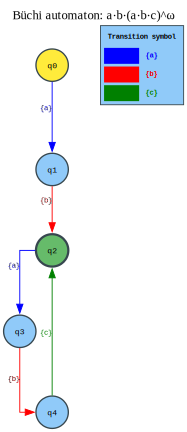

In [3]:
buchi = BuchiAutomaton()
buchi.add_initial_state('q0')
buchi.add_transition('q0', {'a'}, 'q1')
buchi.add_transition('q1', {'b'}, 'q2')
buchi.add_accepting_state('q2')
buchi.add_transition('q2', {'a'}, 'q3')
buchi.add_transition('q3', {'b'}, 'q4')
buchi.add_transition('q4', {'c'}, 'q2')

res = buchi.check_emptiness()
print('witness:', res.witness)

g = draw(buchi, title='Büchi automaton: a·b·(a·b·c)^ω',
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors={'{a}': 'blue', '{b}': 'red', '{c}': 'green'},
         legend_title='Transition symbol')
display.SVG(g.pipe(format='svg'))

## 2. Kripke model

A Kripke model `(S, →, L)` with propositions holding at states.

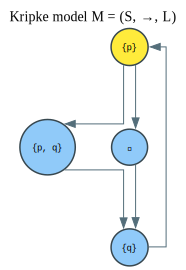

In [3]:
kripke = KripkeModel()
kripke.add_initial_state('s0', {'p'})
kripke.add_state('s1', {'p', 'q'})
kripke.add_state('s2', {'q'})
kripke.add_state('s3', set())

kripke.add_transition('s0', 's1')
kripke.add_transition('s1', 's2')
kripke.add_transition('s2', 's0')
kripke.add_transition('s0', 's3')
kripke.add_transition('s3', 's2')

g = draw(kripke, title='Kripke model M = (S, →, L)',
         node_propositions=kripke.labeling, show_edge_labels=False, use_xlabels=False)
display.SVG(g.pipe(format='svg'))

## 3. Self-loops — infinitely many 'a's

Graphviz renders self-loops beautifully as arcs on the node.

witness: {a}·({a})ω


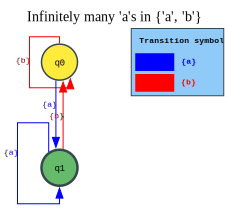

In [4]:
inf_a = BuchiAutomaton()
inf_a.add_initial_state('q0')
inf_a.add_accepting_state('q1')

inf_a.add_transition('q0', {'a'}, 'q1')
inf_a.add_transition('q0', {'b'}, 'q0')  # self-loop
inf_a.add_transition('q1', {'a'}, 'q1')  # self-loop
inf_a.add_transition('q1', {'b'}, 'q0')

res = inf_a.check_emptiness()
print('witness:', res.witness)

g = draw(inf_a, title="Infinitely many 'a's in {'a', 'b'}",
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors={'{a}': 'blue', '{b}': 'red'},
         legend_title='Transition symbol')
display.SVG(g.pipe(format='svg'))

## 4. Intersection — both 'a' and 'b' infinitely often

The intersection of two automata: one accepting infinitely many 'a's, another accepting infinitely many 'b's. The product automaton accepts words with *both* 'a' and 'b' infinitely often.

The product state space is `Q₁ × Q₂ × {1, 2}` with a tracking bit that toggles between the two accepting sets. The accepting states are those where bit=1 (watching for `a`).

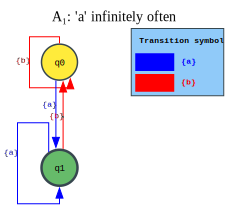

In [5]:
from tutorials.buchi import intersect

def inf_symbol(symbol, other):
    """Automaton accepting 'symbol' infinitely often over alphabet {symbol, other}."""
    a = BuchiAutomaton()
    a.add_initial_state('s0')
    a.add_accepting_state('s1')
    a.add_transition('s0', {symbol}, 's1')
    a.add_transition('s0', {other}, 's0')  # self-loop
    a.add_transition('s1', {symbol}, 's1')  # self-loop (accepting)
    a.add_transition('s1', {other}, 's0')
    return a

a_inf = inf_symbol('a', 'b')      # 'a' infinitely often
b_inf = inf_symbol('b', 'a')      # 'b' infinitely often

g1 = draw(a_inf, title="A₁: 'a' infinitely often",
          initial_color='#ffeb3b', accepting_color='#66bb6a',
          edge_colors={'{a}': 'blue', '{b}': 'red'},
          legend_title='Transition symbol')
display.SVG(g1.pipe(format='svg'))

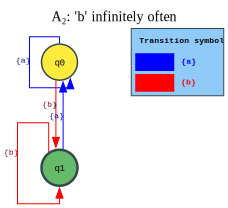

In [6]:
g2 = draw(b_inf, title="A₂: 'b' infinitely often",
          initial_color='#ffeb3b', accepting_color='#66bb6a',
          edge_colors={'{a}': 'blue', '{b}': 'red'},
          legend_title='Transition symbol')
display.SVG(g2.pipe(format='svg'))

Product empty: False
Witness: {a}·({b}{a})ω


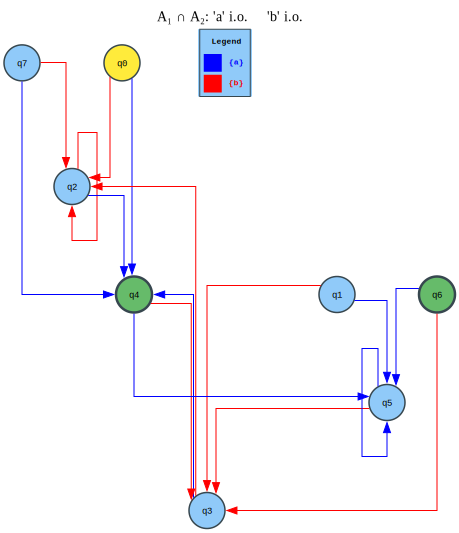

In [7]:
product = intersect(a_inf, b_inf)

res = product.check_emptiness()
print(f'Product empty: {res.is_empty}')
print(f'Witness: {res.witness}')

g = draw(product, title="A₁ ∩ A₂: 'a' i.o. ∧ 'b' i.o.",
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         size='14,10', nodesep=0.8, ranksep=1.0,
         show_edge_labels=False,
         edge_colors={'{a}': 'blue', '{b}': 'red'})
display.SVG(g.pipe(format='svg'))

## 5. GPVW intermediate construction — `old`, `now`, `next` sets

The `ltl_to_buchi_gpvw` function uses the **Gerth–Peled–Vardi–Wolper (GPVW) on-the-fly** algorithm.  Instead of enumerating the closure and elementary sets upfront, GPVW builds states incrementally by expanding *sets of subformula obligations*:

| Set | Meaning |
|-----|---------|
| **old** | Formulas already processed at this state — they hold "right now" |
| **now** | Formulas yet to be processed at this step (empty for finalized states) |
| **nxt** | Formulas deferred to the **next** time step |

Two nodes with the same `old` and `nxt` are **merged** (they represent the same local theory).  The result is a Generalized Büchi Automaton (GBA); one accepting set per `U` sub-formula ensures every Until promise is eventually fulfilled.

Each diagram below shows the **finalized GPVW nodes** (now = ∅) for four simple LTL formulas.  Initial states are yellow, accepting states have a double border and green header.


In [8]:
from tutorials.buchi import ltl_to_buchi_gpvw, Var, F, G, U

from tutorials.buchi.gpvw_ltl_to_buchi import (
    ltl_to_gba_gpvw, to_nnf, formula_untils, INIT, Atom, Not as NNFNot,
)
from tutorials.buchi.visualization_graphviz import draw_gpvw_nodes

def show_gpvw(formula, title):
    """Run GPVW, print the node table, and draw the intermediate node graph."""
    nnf = to_nnf(formula)
    untils = formula_untils(formula)
    _, nodes = ltl_to_gba_gpvw(formula)

    # ── Node table ────────────────────────────────────────────────────────────
    def fmt(fset):
        return "∅" if not fset else "{" + ", ".join(sorted(str(f) for f in fset)) + "}"

    init_names = {n.name for n in nodes if INIT in n.incoming}
    per_acc = [{n.name for n in nodes if (u not in n.old) or (u.right in n.old)} for u in untils]
    fully_acc = set.intersection(*per_acc) if per_acc else {n.name for n in nodes}

    print(f"Formula: {formula}   NNF: {nnf}")
    print(f"Until sub-formulas in NNF: {[str(u) for u in untils]}")
    print(f"\n{'Node':<6} {'Init':<6} {'Acc':<6}  {'old':<40}  {'now':<6}  {'nxt'}")
    print("-" * 90)
    for n in sorted(nodes, key=lambda x: x.name):
        ql = f"q{sorted(nodes, key=lambda x: x.name).index(n)}"
        init = "✓" if n.name in init_names else ""
        acc  = "✓" if n.name in fully_acc  else ""
        print(f"{ql:<6} {init:<6} {acc:<6}  {fmt(n.old):<40}  {'∅':<6}  {fmt(n.next_set)}")

    # ── Graph ─────────────────────────────────────────────────────────────────
    g = draw_gpvw_nodes(nodes, untils, title=title, size="10,5")
    return display.SVG(g.pipe(format="svg"))

Formula: F p   NNF: (true U p)
Until sub-formulas in NNF: ['(true U p)']

Node   Init   Acc     old                                       now     nxt
------------------------------------------------------------------------------------------
q0     ✓      ✓       {(true U p), p}                           ∅       ∅
q1     ✓              {(true U p), true}                        ∅       {(true U p)}
q2            ✓       ∅                                         ∅       ∅


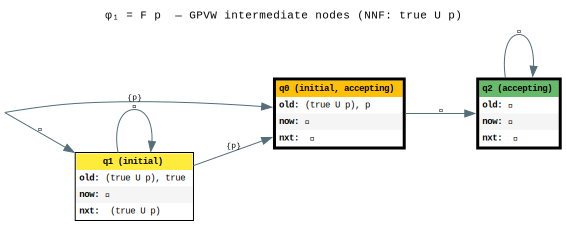

In [9]:
# ── φ₁ : F p  ("eventually p") ───────────────────────────────────────────────
show_gpvw(F(Var('p')), title='φ₁ = F p  — GPVW intermediate nodes (NNF: true U p)')

Formula: G p   NNF: (false R p)
Until sub-formulas in NNF: []

Node   Init   Acc     old                                       now     nxt
------------------------------------------------------------------------------------------
q0     ✓      ✓       {(false R p), p}                          ∅       {(false R p)}


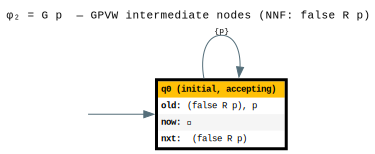

In [10]:
# ── φ₂ : G p  ("always p") ───────────────────────────────────────────────────
show_gpvw(G(Var('p')), title='φ₂ = G p  — GPVW intermediate nodes (NNF: false R p)')

Formula: (p U q)   NNF: (p U q)
Until sub-formulas in NNF: ['(p U q)']

Node   Init   Acc     old                                       now     nxt
------------------------------------------------------------------------------------------
q0     ✓      ✓       {(p U q), q}                              ∅       ∅
q1     ✓              {(p U q), p}                              ∅       {(p U q)}
q2            ✓       ∅                                         ∅       ∅


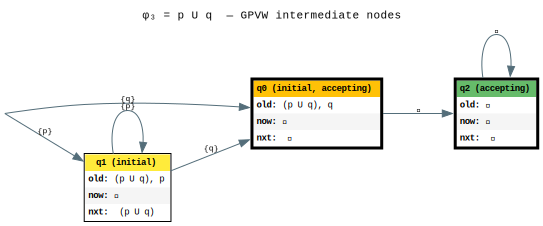

In [11]:
# ── φ₃ : p U q  ("p until q") ────────────────────────────────────────────────
show_gpvw(U(Var('p'), Var('q')), title='φ₃ = p U q  — GPVW intermediate nodes')

Formula: G F p   NNF: (false R (true U p))
Until sub-formulas in NNF: ['(true U p)']

Node   Init   Acc     old                                       now     nxt
------------------------------------------------------------------------------------------
q0     ✓      ✓       {(false R (true U p)), (true U p), p}     ∅       {(false R (true U p))}
q1     ✓              {(false R (true U p)), (true U p), true}  ∅       {(false R (true U p)), (true U p)}


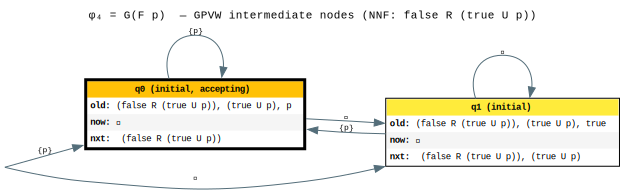

In [12]:
# ── φ₄ : G(F p)  ("p holds infinitely often") ────────────────────────────────
show_gpvw(G(F(Var('p'))), title='φ₄ = G(F p)  — GPVW intermediate nodes (NNF: false R (true U p))')